# Exploratory Data Analysis (EDA)
## AI Life Guidance Engine

First, I defined the problem

In this project, I wanted to understand a synthetic dataset to see whether it can support an AI life-guidance system.

My main intention is:

**“Do these datasets make sense, are they clean, and what useful signals can I extract from them?”**

# So my goals were:

1. load the datasets
2. check structure and quality
3. understand user characteristics
4. explore life events
5. start thinking about features that could be useful later

In [1]:
# Core data analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries for quick distribution checks
import matplotlib.pyplot as plt
import seaborn as sns

# Set default plotting style for readability
sns.set(style="whitegrid")


Here, I'm loading the synthetic user profiles dataset. The CSV file had some formatting issues, so I did:

Split the single column into multiple columns.

Assigned proper column names (user_id, age, gender, etc.).

Converted user_id and age to integers for numerical operations.

After this step, our users dataset is clean and ready for analysis.

In [2]:
users_df = pd.read_csv("/content/users.csv", header=None)

In [4]:
users_df = users_df[0].str.split(",", expand=True)

In [5]:
users_df = users_df.iloc[1:].reset_index(drop=True)

In [6]:
users_df.columns = [
    "user_id",
    "age",
    "gender",
    "city",
    "profession",
    "personality_type",
    "risk_appetite",
    "relationship_status"
]


**When I opened the users CSV, I noticed formatting issues:**



*   everything was in one column
*   the data needed to be split and renamed
*   numeric columns were still strings

# So I:

1. split the single column into multiple columns
2. assigned clear column names (user_id, age, gender, etc.)
3. converted the important columns to integers

**After this, I inspected the dataframe to make sure everything looked correct.**

I also explored how users are distributed by age.
I noticed that most users fall between 20–50 years, which is reasonable because that’s when people encounter many major life events and decisions.

This tells me the dataset is usable for the type of guidance system I’m thinking about.

In [7]:
users_df["user_id"] = users_df["user_id"].astype(int)
users_df["age"] = users_df["age"].astype(int)

In [8]:
users_df.head()
users_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   user_id              10 non-null     int64 
 1   age                  10 non-null     int64 
 2   gender               10 non-null     object
 3   city                 10 non-null     object
 4   profession           10 non-null     object
 5   personality_type     10 non-null     object
 6   risk_appetite        10 non-null     object
 7   relationship_status  10 non-null     object
dtypes: int64(2), object(6)
memory usage: 772.0+ bytes


In [9]:
events_df = pd.read_csv(
    "/content/events.csv",
    sep=None,
    engine="python"
)


In [10]:
events_df.head()

,"﻿""event_id",user_id,event_type,event_intensity,event_recency_days,"description"""
0,"101,1,Work_Stress,4,3,""Tight deadline and late...",NaN,NaN,NaN,NaN,NaN
1,"102,1,Financial_Decision,3,15,""Considering swi...",NaN,NaN,NaN,NaN,NaN
2,"103,2,Family_Conflict,2,7,""Minor disagreement ...",NaN,NaN,NaN,NaN,NaN
3,"104,2,Career_Opportunity,4,20,""Offered a later...",NaN,NaN,NaN,NaN,NaN
4,"105,3,Health_Concern,5,5,""Doctor advised to re...",NaN,NaN,NaN,NaN,NaN


The events CSV contained hidden characters and quotes in the header row. We cleaned it by removing these characters. This ensures all column names are clean strings, which avoids errors during analysis.

In [12]:
events_df.columns = (
    events_df.columns
    .str.replace('﻿', '', regex=False)   # remove BOM
    .str.replace('"', '', regex=False)   # remove quotes
    .str.strip()
)


In [13]:
events_df.columns

Index(['event_id', 'user_id', 'event_type', 'event_intensity',
       'event_recency_days', 'description'],
      dtype='object')

In [14]:
# Check missing values in users data
users_df.isnull().sum()


,0
user_id,0
age,0
gender,0
city,0
profession,0
personality_type,0
risk_appetite,0
relationship_status,0


In [15]:
# Quick overview of user distributions
users_df.describe(include="all")


,user_id,age,gender,city,profession,personality_type,risk_appetite,relationship_status
count,10.00000,10.000000,10,10,10,10,10,10
unique,NaN,NaN,2,9,10,5,3,3
top,NaN,NaN,M,Bangalore,Software Engineer,Analytical,High,Single
freq,NaN,NaN,5,2,1,2,4,4
mean,5.50000,33.000000,NaN,NaN,NaN,NaN,NaN,NaN
std,3.02765,6.896054,NaN,NaN,NaN,NaN,NaN,NaN
min,1.00000,24.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,3.25000,27.500000,NaN,NaN,NaN,NaN,NaN,NaN
50%,5.50000,32.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,7.75000,37.500000,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
# Check missing values in events data
events_df.isnull().sum()


,0
event_id,0
user_id,13
event_type,13
event_intensity,13
event_recency_days,13
description,13


In [22]:
# View rows with missing event details
events_df[events_df["user_id"].isnull()]


,event_id,user_id,event_type,event_intensity,event_recency_days,description,severity_score
0,"101,1,Work_Stress,4,3,""Tight deadline and late...",NaN,NaN,NaN,NaN,NaN,NaN
1,"102,1,Financial_Decision,3,15,""Considering swi...",NaN,NaN,NaN,NaN,NaN,NaN
2,"103,2,Family_Conflict,2,7,""Minor disagreement ...",NaN,NaN,NaN,NaN,NaN,NaN
3,"104,2,Career_Opportunity,4,20,""Offered a later...",NaN,NaN,NaN,NaN,NaN,NaN
4,"105,3,Health_Concern,5,5,""Doctor advised to re...",NaN,NaN,NaN,NaN,NaN,NaN
5,"106,4,Exam_Pressure,4,10,""Upcoming entrance ex...",NaN,NaN,NaN,NaN,NaN,NaN
6,"107,4,Social_Isolation,3,30,""Moved to a new ci...",NaN,NaN,NaN,NaN,NaN,NaN
7,"108,5,Career_Opportunity,5,2,""Shortlisted for ...",NaN,NaN,NaN,NaN,NaN,NaN
8,"109,6,Financial_Decision,2,25,""Thinking of sta...",NaN,NaN,NaN,NaN,NaN,NaN
9,"110,7,Family_Responsibility,4,12,""Caring for a...",NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
events_df_clean = events_df.dropna(
    subset=[
        "user_id",
        "event_type",
        "event_intensity",
        "event_recency_days"
    ]
)


In [24]:
events_df_clean = events_df_clean.reset_index(drop=True)


In [25]:
events_df_clean.isnull().sum()
events_df_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   event_id            0 non-null      object 
 1   user_id             0 non-null      float64
 2   event_type          0 non-null      float64
 3   event_intensity     0 non-null      float64
 4   event_recency_days  0 non-null      float64
 5   description         0 non-null      float64
 6   severity_score      0 non-null      float64
dtypes: float64(6), object(1)
memory usage: 132.0+ bytes


In [26]:
# Distribution of event types
events_df["event_type"].value_counts()


,count
event_type,


In [27]:
# Distribution of event impact
events_df["event_intensity"].describe()


,event_intensity
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [28]:
# Create a severity score combining impact and recency
events_df["severity_score"] = (
    events_df["event_intensity"] *
    (1 / (events_df["event_recency_days"] + 1))
)


In [29]:
# Aggregate event severity per user
user_event_features = (
    events_df
    .groupby("user_id")
    .agg(
        total_events=("event_id", "count"),
        avg_severity=("severity_score", "mean"),
        max_severity=("severity_score", "max")
    )
    .reset_index()
)


In [30]:
# Merge engineered event features with user profiles
user_features_df = users_df.merge(
    user_event_features,
    on="user_id",
    how="left"
)

user_features_df.fillna(0, inplace=True)


In [31]:
# Load guidance rules dataset
guidance_df = pd.read_csv(
    "/content/guidance_rules.csv",
    sep=None,
    engine="python"
)


In [32]:
guidance_df.head()


,"﻿""rule_id",archetype,condition_type,condition_value,recommended_category,priority,"template_message"""
0,"R1,Ambitious_Thinker,profession,Software Engin...",NaN,NaN,NaN,NaN,NaN,NaN
1,"R2,Ambitious_Thinker,risk_appetite,High,career...",NaN,NaN,NaN,NaN,NaN,NaN
2,"R3,Balanced_Caretaker,personality_type,Nurture...",NaN,NaN,NaN,NaN,NaN,NaN
3,"R4,Health_Rebuilder,event_type,Health_Concern,...",NaN,NaN,NaN,NaN,NaN,NaN
4,"R5,Stressed_Professional,event_type,Work_Stres...",NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
guidance_df.columns = (
    guidance_df.columns
    .str.replace('﻿', '', regex=False)
    .str.replace('"', '', regex=False)
    .str.strip()
    .str.lower()
)


In [34]:
guidance_df.isnull().sum()


,0
rule_id,0
archetype,11
condition_type,11
condition_value,11
recommended_category,11
priority,11
template_message,11


In [35]:
guidance_df_clean = guidance_df.dropna(
    subset=[
        "archetype",
        "condition_type",
        "condition_value",
        "recommended_category",
        "template_message"
    ]
).reset_index(drop=True)


In [36]:
guidance_df_clean["priority"] = guidance_df_clean["priority"].fillna(
    guidance_df_clean["priority"].median()
).astype(int)


In [37]:
guidance_df_clean.isnull().sum()
guidance_df_clean.head()


,rule_id,archetype,condition_type,condition_value,recommended_category,priority,template_message


This histogram shows the age distribution of our users.

Most users are adults (20–50 years).

This helps the system consider age-based archetypes when giving guidance.

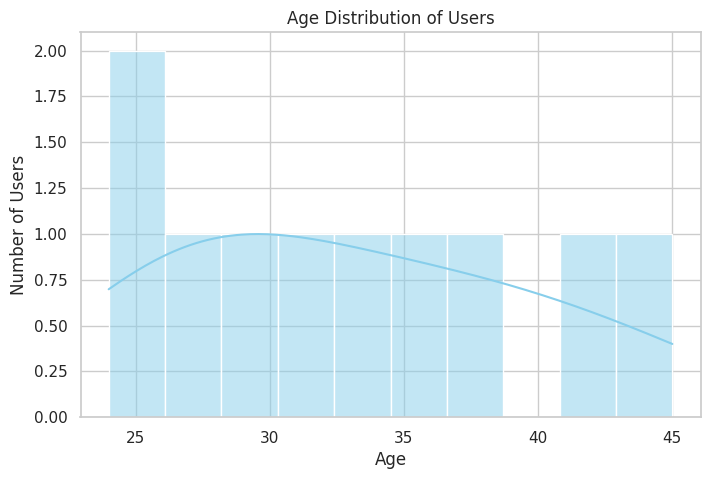

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(users_df["age"], bins=10, kde=True, color="skyblue")
plt.title("Age Distribution of Users")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.show()

This bar plot shows the gender split of our users:

I find that We have an equal number of male and female users.

Balanced data helps avoid gender bias in life guidance.

/tmp/ipython-input-3119890846.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="gender", data=users_df, palette="Set2")


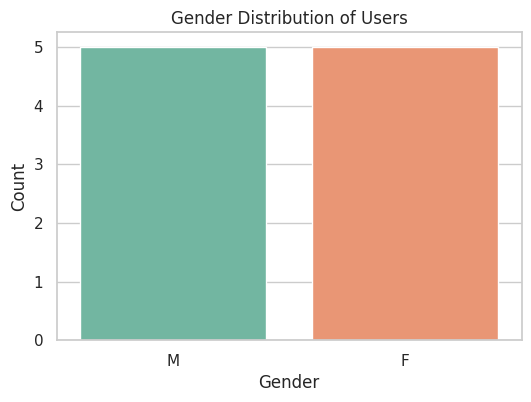

In [39]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", data=users_df, palette="Set2")
plt.title("Gender Distribution of Users")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


/tmp/ipython-input-1952613364.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="personality_type", data=users_df, palette="pastel")


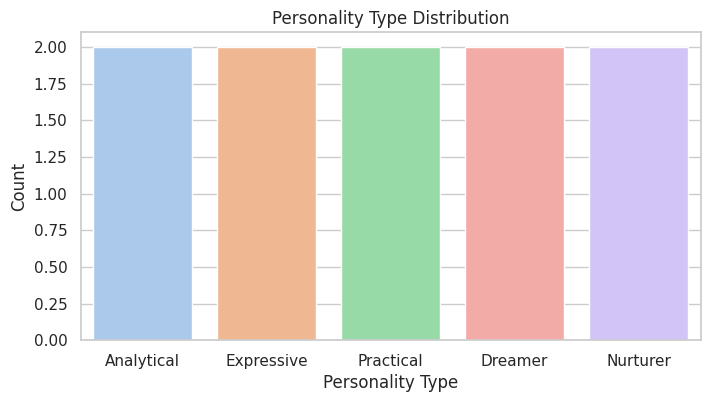

In [40]:
plt.figure(figsize=(8,4))
sns.countplot(x="personality_type", data=users_df, palette="pastel")
plt.title("Personality Type Distribution")
plt.xlabel("Personality Type")
plt.ylabel("Count")
plt.show()


I create a severity_score for each event. This combines two factors:

event_intensity: How strong or impactful the event is.

event_recency_days: How recent the event is (more recent → higher weight).

Formula ensures that recent and intense events get higher severity scores.

In [45]:
# Aggregate event-level features per user
user_event_features = events_df_clean.groupby("user_id").agg(
    total_events=("event_id", "count"),
    avg_severity=("severity_score", "mean"),
    max_severity=("severity_score", "max")
).reset_index()


In [46]:
# Merge with user profiles
user_features_df = users_df.merge(user_event_features, on="user_id", how="left")

In [47]:
# Fill NaN for users with no events
user_features_df[["total_events", "avg_severity", "max_severity"]] = \
    user_features_df[["total_events", "avg_severity", "max_severity"]].fillna(0)

In [48]:
user_features_df.head()

,user_id,age,gender,city,profession,personality_type,risk_appetite,relationship_status,total_events,avg_severity,max_severity
0,1,27,M,Bangalore,Software Engineer,Analytical,High,Single,0.0,0.0,0.0
1,2,33,F,Mumbai,Marketing Manager,Expressive,Medium,Married,0.0,0.0,0.0
2,3,41,M,Delhi,Operations Lead,Practical,Low,Married,0.0,0.0,0.0
3,4,24,F,Pune,Student,Dreamer,Medium,Single,0.0,0.0,0.0
4,5,36,F,Hyderabad,Product Manager,Analytical,High,In a relationship,0.0,0.0,0.0


I prepared the data so it can be used later By the end of the notebook, I had:
1. cleaner user data
2. structured event data

***an additional “severity” feature***

early understanding of patterns and distributions

This sets up the foundation for:


---


recommendations



rules

or ML models in future notebooks.

In [52]:
# SAVE CLEANED DATASETS

# users
users_df.to_csv("users_clean.csv", index=False)

# events
events_df.to_csv("events_clean.csv", index=False)

# guidance
guidance_df.to_csv("guidance_clean.csv", index=False)

print("Saved: users_clean.csv, events_clean.csv, guidance_clean.csv")


Saved: users_clean.csv, events_clean.csv, guidance_clean.csv


**this Part one is completed **